In [5]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

import shap
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("country_year_modeling_dataset_ready.csv") 
print(df.shape)
df.head()

(5712, 12)


,iso3c,country,year,mmr,gdp_pc,health_exp_gdp,fertility,skilled_births,pm25,heat_index35_days,cooling_degree_days,log_mmr
0,AFE,Africa Eastern and Southern,2000,612.0,706.727261,5.657523,5.549893,40.977528,26.783513,0.0,3061.85,6.418365
1,AFE,Africa Eastern and Southern,2001,586.0,625.827815,5.803267,5.501766,98.500000,26.809926,0.0,3255.66,6.375025
2,AFE,Africa Eastern and Southern,2002,564.0,630.512328,5.408213,5.449696,98.900000,26.718091,0.0,3474.73,6.336826
3,AFE,Africa Eastern and Southern,2003,537.0,815.432296,5.989670,5.407328,98.900000,26.580603,0.0,3506.74,6.287859
4,AFE,Africa Eastern and Southern,2004,516.0,989.015464,6.069927,5.381308,98.500000,26.475208,0.0,3467.88,6.248043


In [9]:
features = [
    "gdp_pc",
    "health_exp_gdp",
    "fertility",
    "skilled_births",
    "pm25",
    "heat_index35_days",
    "cooling_degree_days"
]

features = [f for f in features if f in df.columns]
print("Features:", features)

X = df[features].copy()
y = df["log_mmr"].copy() if "log_mmr" in df.columns else np.log1p(df["mmr"])

Features: ['gdp_pc', 'health_exp_gdp', 'fertility', 'skilled_births', 'pm25', 'heat_index35_days', 'cooling_degree_days']


In [11]:
split_year = 2018

train = df[df["year"] <= split_year].copy()
test  = df[df["year"] > split_year].copy()

X_train = train[features]
y_train = train["log_mmr"] if "log_mmr" in train.columns else np.log1p(train["mmr"])

X_test = test[features]
y_test = test["log_mmr"] if "log_mmr" in test.columns else np.log1p(test["mmr"])

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4522, 7) Test: (1190, 7)


In [13]:
best_model = GradientBoostingRegressor(random_state=42)
best_model.fit(X_train, y_train)

preds_log = best_model.predict(X_test)


preds_mmr = np.expm1(preds_log)
true_mmr  = np.expm1(y_test)

print("MAE (MMR scale):", mean_absolute_error(true_mmr, preds_mmr))
print("RMSE (MMR scale):", np.sqrt(mean_squared_error(true_mmr, preds_mmr)))
print("R2 (log scale):", r2_score(y_test, preds_log))

MAE (MMR scale): 64.26546341359467
RMSE (MMR scale): 120.12362978407579
R2 (log scale): 0.7412383518029251


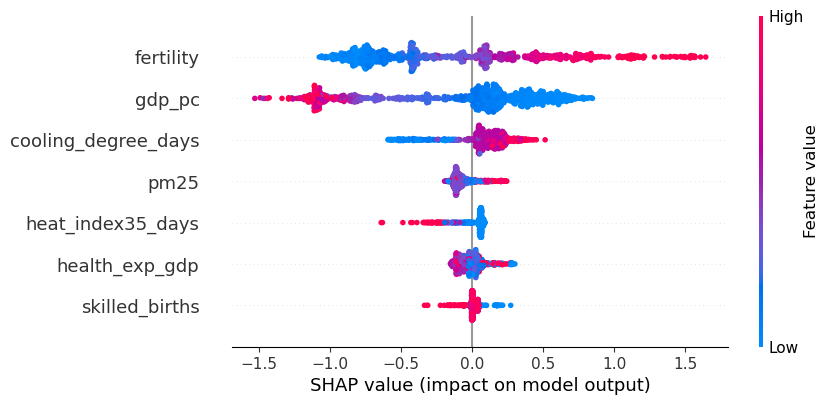

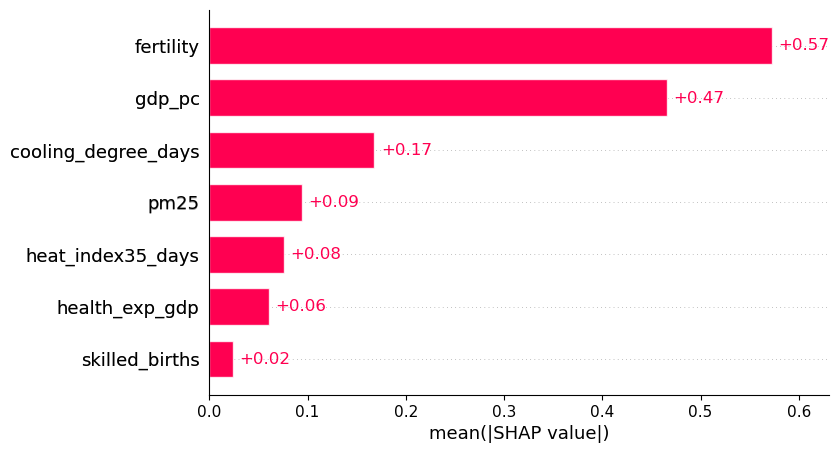

In [15]:
# SHAP (beeswarm + bar)
X_bg = X_train.sample(min(500, len(X_train)), random_state=42)
X_explain = X_test.sample(min(1000, len(X_test)), random_state=42)

explainer = shap.Explainer(best_model, X_bg)
shap_values = explainer(X_explain)

shap.plots.beeswarm(shap_values, max_display=12)
shap.plots.bar(shap_values, max_display=12)

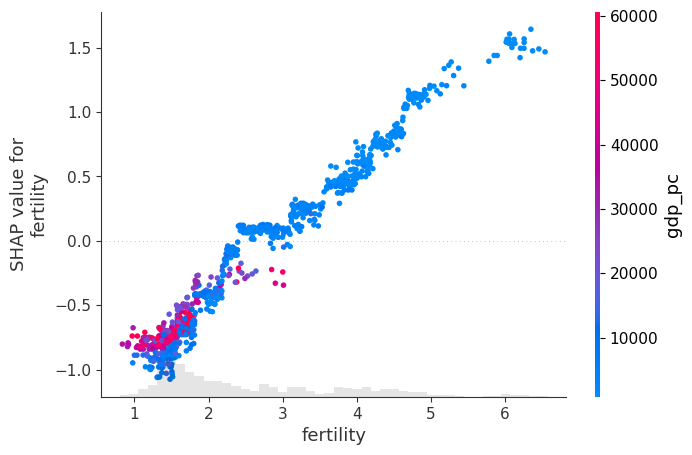

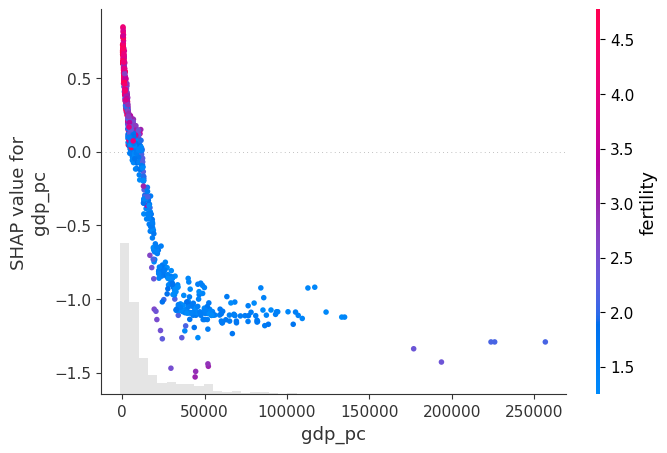

In [17]:
#SHAP direction plots (fertility + gdp)
if "fertility" in features:
    shap.plots.scatter(shap_values[:, "fertility"], color=shap_values)

if "gdp_pc" in features:
    shap.plots.scatter(shap_values[:, "gdp_pc"], color=shap_values)

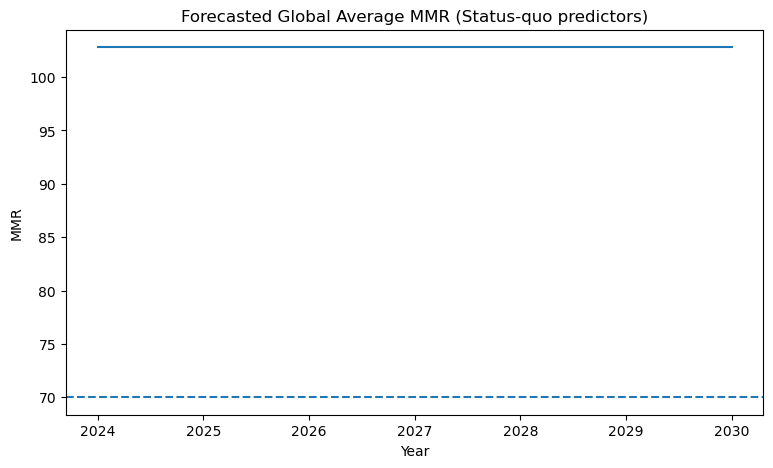

In [19]:
# Train on full dataset for forecasting to 2030
X_all = df[features]
y_all = df["log_mmr"] if "log_mmr" in df.columns else np.log1p(df["mmr"])
best_model.fit(X_all, y_all)

latest = df.sort_values("year").groupby("iso3c").tail(1).copy()

future_years = list(range(2024, 2031))
future = pd.concat([latest.assign(year=yr) for yr in future_years], ignore_index=True)

future["pred_log_mmr"] = best_model.predict(future[features])
future["pred_mmr"] = np.expm1(future["pred_log_mmr"])

global_forecast = future.groupby("year")["pred_mmr"].mean().reset_index()

plt.figure(figsize=(9,5))
plt.plot(global_forecast["year"], global_forecast["pred_mmr"])
plt.axhline(70, linestyle="--")
plt.title("Forecasted Global Average MMR (Status-quo predictors)")
plt.xlabel("Year")
plt.ylabel("MMR")
plt.show()

/var/folders/bk/7mkp0vz90ksf2fzc1gkl0wlm0000gn/T/ipykernel_14960/2159084909.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend = df_sorted.groupby("iso3c").apply(lambda g: compute_trend(g, col))
/var/folders/bk/7mkp0vz90ksf2fzc1gkl0wlm0000gn/T/ipykernel_14960/2159084909.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  trend = df_sorted.groupby("iso3c").apply(lambda g: compute_trend(g, col))
/var

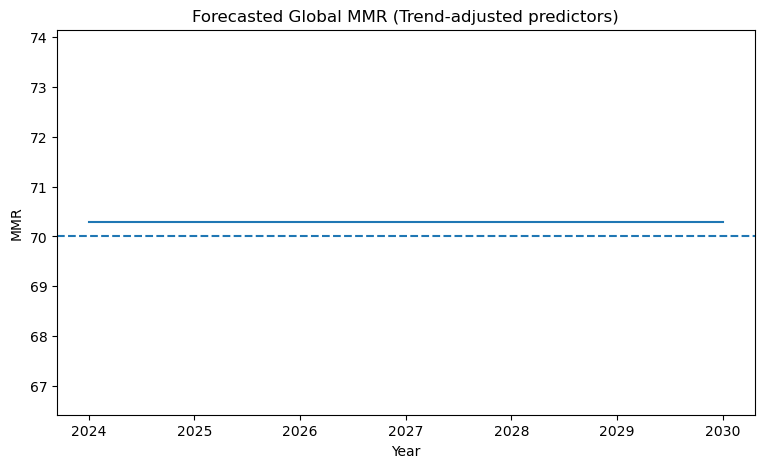

In [21]:
# Train on full dataset
X_all = df[features]
y_all = df["log_mmr"] if "log_mmr" in df.columns else np.log1p(df["mmr"])
best_model.fit(X_all, y_all)

#last 5-year trend for each country
df_sorted = df.sort_values(["iso3c", "year"])

def compute_trend(group, col):
    if len(group) >= 5:
        return group[col].iloc[-1] - group[col].iloc[-5]
    else:
        return 0

latest = df_sorted.groupby("iso3c").tail(1).copy()

#simple linear trend continuation
future_years = list(range(2024, 2031))
future_frames = []

for yr in future_years:
    temp = latest.copy()
    temp["year"] = yr
    
    for col in features:
        if col in df.columns:
            trend = df_sorted.groupby("iso3c").apply(lambda g: compute_trend(g, col))
            temp[col] = temp[col] + trend.values
    
    future_frames.append(temp)

future = pd.concat(future_frames, ignore_index=True)

future["pred_log_mmr"] = best_model.predict(future[features])
future["pred_mmr"] = np.expm1(future["pred_log_mmr"])

global_forecast = future.groupby("year")["pred_mmr"].mean().reset_index()

plt.figure(figsize=(9,5))
plt.plot(global_forecast["year"], global_forecast["pred_mmr"])
plt.axhline(70, linestyle="--")
plt.title("Forecasted Global MMR (Trend-adjusted predictors)")
plt.xlabel("Year")
plt.ylabel("MMR")
plt.show()

In [23]:
#5-year slope per country for each feature
df_sorted = df.sort_values(["iso3c", "year"]).copy()

def five_year_slope(g, col):
    g = g.dropna(subset=[col])
    if g.shape[0] < 5:
        return 0.0
    # last 5 points
    g5 = g.tail(5)
    # slope per year = (last - first) / (years span)
    dy = g5[col].iloc[-1] - g5[col].iloc[0]
    dx = g5["year"].iloc[-1] - g5["year"].iloc[0]
    return float(dy / dx) if dx != 0 else 0.0

# slopes: dict of Series indexed by iso3c
slopes = {
    col: df_sorted.groupby("iso3c", group_keys=False).apply(lambda g: five_year_slope(g, col))
    for col in features
}

/var/folders/bk/7mkp0vz90ksf2fzc1gkl0wlm0000gn/T/ipykernel_14960/2594258335.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  col: df_sorted.groupby("iso3c", group_keys=False).apply(lambda g: five_year_slope(g, col))
/var/folders/bk/7mkp0vz90ksf2fzc1gkl0wlm0000gn/T/ipykernel_14960/2594258335.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  col: df_sorted.groupby("iso3c", group_keys=False).apply(lambd

In [25]:
#future predictors using slopes
latest = df_sorted.groupby("iso3c").tail(1).copy()

future_years = list(range(2024, 2031))
future_frames = []

for yr in future_years:
    temp = latest.copy()
    temp["year"] = yr
    years_ahead = yr - temp["year"].min()

    # apply slope * (yr - last_year_for_that_country)
    for col in features:
        last_year = temp["year"].copy()  # currently set to yr, used latest year stored before overwrite
    future_frames.append(temp)

#store each country last observed year before loop
latest = df_sorted.groupby("iso3c").tail(1).copy()
latest_year = latest.set_index("iso3c")["year"]

future_frames = []
for yr in future_years:
    temp = latest.copy()
    temp["year"] = yr
    for col in features:
        s = slopes[col]
        # align by iso3c
        temp[col] = temp.apply(
            lambda r: r[col] + s.get(r["iso3c"], 0.0) * (yr - latest_year.get(r["iso3c"], yr)),
            axis=1
        )
    future_frames.append(temp)

future = pd.concat(future_frames, ignore_index=True)

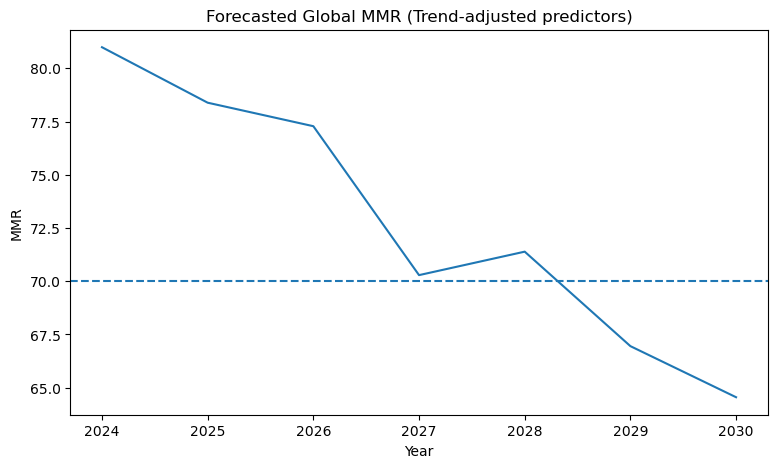

,year,pred_mmr
0,2024,80.988470
1,2025,78.383437
2,2026,77.279856
3,2027,70.286713
4,2028,71.388519
5,2029,66.952289
6,2030,64.553340


In [27]:
future["pred_log_mmr"] = best_model.predict(future[features])
future["pred_mmr"] = np.expm1(future["pred_log_mmr"])

global_forecast = future.groupby("year")["pred_mmr"].mean().reset_index()

plt.figure(figsize=(9,5))
plt.plot(global_forecast["year"], global_forecast["pred_mmr"])
plt.axhline(70, linestyle="--")
plt.title("Forecasted Global MMR (Trend-adjusted predictors)")
plt.xlabel("Year")
plt.ylabel("MMR")
plt.show()

global_forecast

In [29]:
#countries that miss SDG 70 in 2030
future.to_csv("forecast_2024_2030_trend_adjusted.csv", index=False)

mmr_2030 = future[future["year"] == 2030][["country", "iso3c", "pred_mmr"]].copy()
mmr_2030["above_70"] = mmr_2030["pred_mmr"] > 70

print("Countries above 70 in 2030:", mmr_2030["above_70"].mean())

mmr_2030.sort_values("pred_mmr", ascending=False).head(15)

Countries above 70 in 2030: 0.31932773109243695


,country,iso3c,pred_mmr,above_70
1429,Afghanistan,AFG,685.626386,True
1633,Chad,TCD,509.797229,True
1459,Central African Republic,CAF,422.146368,True
1442,Burundi,BDI,401.053771,True
1567,Mali,MLI,335.890878,True
1580,Niger,NER,306.766911,True
1619,"Somalia, Fed. Rep.",SOM,255.781580,True
1467,"Congo, Dem. Rep.",COD,250.960756,True
1655,Uzbekistan,UZB,225.886742,True
1612,Sudan,SDN,200.038621,True


In [31]:
top_miss = mmr_2030[mmr_2030["above_70"]].sort_values("pred_mmr", ascending=False).head(20)
top_hit  = mmr_2030[~mmr_2030["above_70"]].sort_values("pred_mmr").head(20)

top_miss, top_hit

(                                     country iso3c    pred_mmr  above_70
 1429                             Afghanistan   AFG  685.626386      True
 1633                                    Chad   TCD  509.797229      True
 1459                Central African Republic   CAF  422.146368      True
 1442                                 Burundi   BDI  401.053771      True
 1567                                    Mali   MLI  335.890878      True
 1580                                   Niger   NER  306.766911      True
 1619                      Somalia, Fed. Rep.   SOM  255.781580      True
 1467                        Congo, Dem. Rep.   COD  250.960756      True
 1655                              Uzbekistan   UZB  225.886742      True
 1612                                   Sudan   SDN  200.038621      True
 1444                                   Benin   BEN  196.931104      True
 1598                Pre-demographic dividend   PRE  191.398346      True
 1430              Africa Western and 

In [33]:
#scenario forecasts
##Scenario 1: Development boost (fertility down, skilled births up, GDP up)
##Scenario 2: Climate stress (heat index up, PM2.5 up)
def scenario_adjust(future_df, scenario="baseline"):
    out = future_df.copy()

    if scenario == "development_boost":
        if "fertility" in features:
            out["fertility"] = out["fertility"] * 0.97  # ~3% lower
        if "skilled_births" in features:
            out["skilled_births"] = np.clip(out["skilled_births"] + 2, 0, 100)
        if "gdp_pc" in features:
            out["gdp_pc"] = out["gdp_pc"] * 1.03

    if scenario == "climate_stress":
        if "heat_index35_days" in features:
            out["heat_index35_days"] = out["heat_index35_days"] * 1.10
        if "pm25" in features:
            out["pm25"] = out["pm25"] * 1.10

    out["pred_log_mmr"] = best_model.predict(out[features])
    out["pred_mmr"] = np.expm1(out["pred_log_mmr"])
    return out

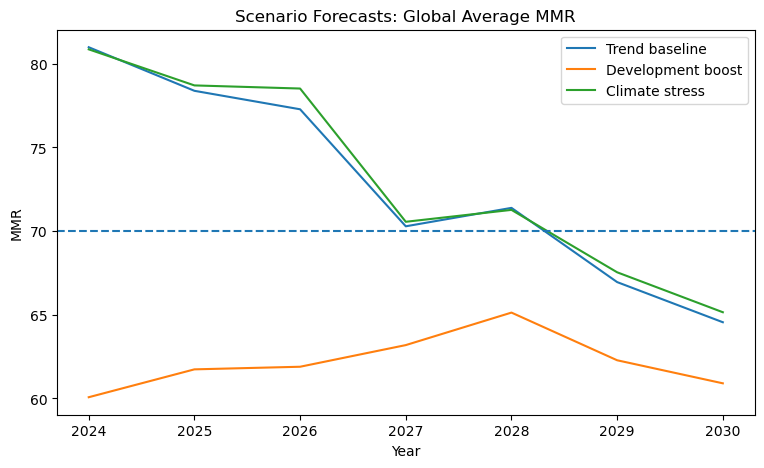

In [35]:
base = future.copy()
dev  = scenario_adjust(future, "development_boost")
clim = scenario_adjust(future, "climate_stress")

g_base = base.groupby("year")["pred_mmr"].mean()
g_dev  = dev.groupby("year")["pred_mmr"].mean()
g_clim = clim.groupby("year")["pred_mmr"].mean()

plt.figure(figsize=(9,5))
plt.plot(g_base.index, g_base.values, label="Trend baseline")
plt.plot(g_dev.index,  g_dev.values,  label="Development boost")
plt.plot(g_clim.index, g_clim.values, label="Climate stress")
plt.axhline(70, linestyle="--")
plt.title("Scenario Forecasts: Global Average MMR")
plt.xlabel("Year")
plt.ylabel("MMR")
plt.legend()
plt.show()

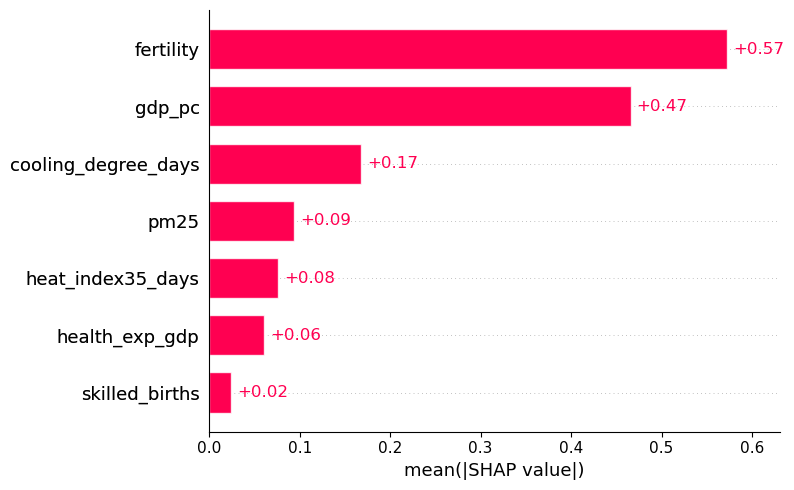

In [37]:
plt.figure()
shap.plots.bar(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=200, bbox_inches="tight")
plt.show()